## Movement

In [35]:
import numpy as np

import matplotlib.pyplot as plt
import math

import robomimic.dev.hparam.movements as Movements
import robomimic.dev.smoothness_metrics.compute_smoothness_metrics as Metrics

In [36]:
def sparc_previous(positions, dt, padlevel=4, fc=20.0, amp_th=0.05, return_data=False):
    if len(positions) < 2:
        return 0.0

    speed = positions

    # If there's not enough data, return 0.0
    if len(speed) < 2:
        return 0.0

    # Compute FFT of the speed
    # rfft gives us the positive frequencies only
    speed_fft = np.fft.rfft(speed)
    freqs = np.fft.rfftfreq(len(speed), d=dt)

    # Compute arc length in the frequency domain
    # arc_length = sum over i of sqrt((Δfreq)^2 + (Δ|FFT|)^2)
    arc_length = 0.0
    for i in range(len(freqs) - 1):
        df = freqs[i+1] - freqs[i]
        dmag = np.abs(speed_fft[i+1]) - np.abs(speed_fft[i])
        arc_length += np.sqrt(df**2 + dmag**2)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-8
    sparc = -math.log(arc_length + epsilon)

    return sparc, (freqs, speed_fft), (freqs, speed_fft)

In [37]:
def sparc_official(positions, dt, padlevel=4, fc=20.0, amp_th=0.05, return_data=False):
    if len(positions) < 2:
        print("hi")
        return 0.0

    fs = int(1/dt)
    
    # vel = (positions[1:] - positions[:-1]) / dt
    # speed = np.linalg.norm(vel, axis = 1)
    speed = positions

    nfft = int(pow(2, np.ceil(np.log2(len(speed)))+padlevel))

    f = np.arange(0, fs, fs / nfft)
    Mf = abs(np.fft.fft(speed, nfft))
    Mf = Mf / max(Mf)

    # maximum frequency cut
    fc_inx = ((f <= fc) * 1).nonzero()
    f_sel  = f[fc_inx]
    Mf_sel = Mf[fc_inx]

    # minimum V0 cut
    inx = ((Mf_sel >= amp_th) * 1).nonzero()[0]
    fc_inx = range(inx[0], inx[-1] + 1)
    f_sel = f_sel[fc_inx]
    Mf_sel = Mf_sel[fc_inx]

    sparc = -np.sqrt(
        (np.diff(f_sel) / (f_sel[-1] - f_sel[0])) ** 2 + \
        (np.diff(Mf_sel))** 2
    ).sum()
    
    if return_data:
        return sparc, (f, Mf), (f_sel, Mf_sel)
    else:
        return sparc

/home/wjung85/miniconda3/envs/fast_il/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/wjung85/miniconda3/envs/fast_il/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/wjung85/miniconda3/envs/fast_il/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/wjung85/miniconda3/envs/fast_il/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/wjung85/miniconda3/envs/fast_il/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary 

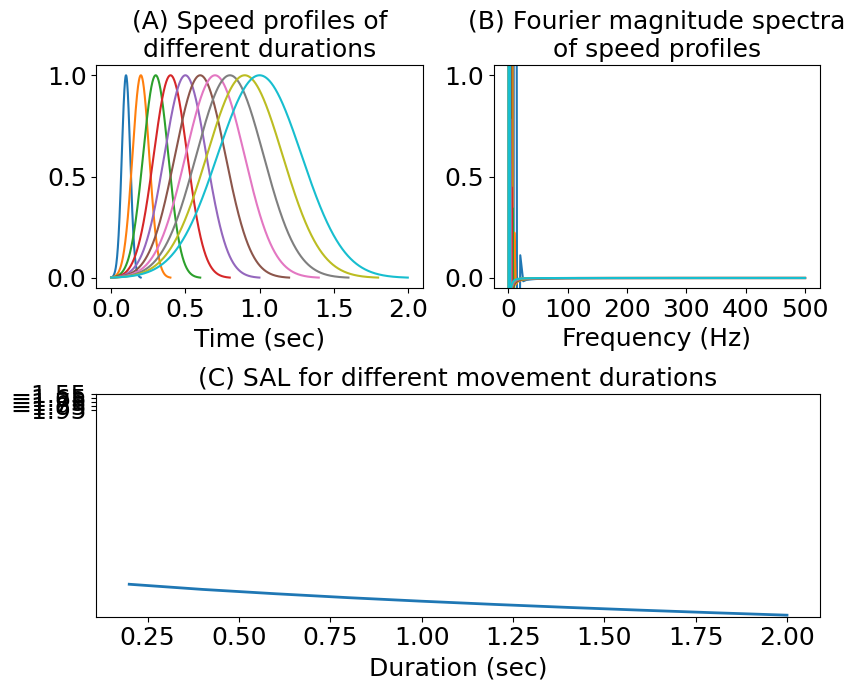

In [38]:
# Guassian movement parameters.
ts = 0.001
amp = 1.0
dur = np.linspace(0.2, 2.0, num=10)
loc = dur / 2.0
times = [np.arange(0., _d, ts) for _d in dur]

# Index of movement with duration 1 sec
dur_inx = np.nonzero(dur == 1.0)[0][0]

# Gaussian movements
moves = [Movements.gaussian_discrete_movement(amp=amp, 
                     dur=dur[i],
                     loc=loc[i], 
                     time=times[i]) for i in range(len(dur))]


# Estimate smoothness using SAL.
sal = np.zeros(len(dur))
_spec = [0] * len(dur)

# The SPARC function is used to estimate smoothness. The SPARC is equal to the 
# SAL when the amp_th is set to zero, and fc is set to 20Hz.
for i in range(0, len(dur)):
    sal[i], _, _spec[i] = sparc_previous(moves[i], dt=ts, padlevel=4, fc=10., amp_th=0.05, return_data=True)
    
# Plot data.
fig = plt.figure(figsize=(8.5,7))
# speed profile plot
plt.subplot2grid(shape=(2,2), loc=(0,0), rowspan=1, colspan=1)
for i in range(0, len(dur), 1):
    plt.plot(times[i], moves[i], lw=1.5)
plt.ylim(-0.05, 1.05)
plt.title('(A) Speed profiles of\ndifferent durations', fontsize=18)
plt.xlabel('Time (sec)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks([0., 0.5, 1.0], fontsize=18)

# Fourier spectrum plot.
plt.subplot2grid(shape=(2,2), loc=(0,1), rowspan=1, colspan=1)
for i in range(0, len(dur), 1):
    plt.plot(_spec[i][0], _spec[i][1], lw=1.5)
plt.ylim(-0.05, 1.05)
plt.title('(B) Fourier magnitude spectra\nof speed profiles', fontsize=18)
plt.xlabel('Frequency (Hz)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks([0., 0.5, 1.0], fontsize=18)

# Change of SAL with movement duration.
plt.subplot2grid(shape=(2,2), loc=(1,0), rowspan=1, colspan=2)
plt.plot(dur, sal, lw=2)  #plot(dur, sal - sal[dur_inx], lw=2)
plt.title('(C) SAL for different movement durations', fontsize=18)
plt.xlabel('Duration (sec)', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(np.arange(-1.95, -1.5, 0.1), fontsize=18)

plt.tight_layout()

In [9]:
moves[0].shape

(200,)